# Data Processing

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize AEV computer;
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)
    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    return torchani.AEVComputer(Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species)

aev_computer = init_aev_computer()

# Load ANI dataset
def load_ani_dataset(dspath):
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']
    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return list(dataset)

data_list = load_ani_dataset("./ani_gdb_s01_to_s04.h5")

Using device: cpu


# Model

In [2]:
class AtomicNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.layers(x)

print("done")

done


# Training

In [2]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch

    def train(self, train_data, val_data):
        self.model.train()
        train_loader = train_data.collate(self.batch_size).cache()
        val_loader = val_data.collate(self.batch_size).cache()
        loss_func = nn.MSELoss()

        for _ in range(self.epoch):
            for batch in train_loader:
                species = batch['species'].to(device)
                coordinates = batch['coordinates'].to(device)
                true_energies = batch['energies'].to(device).float()
                self.optimizer.zero_grad()
                _, pred_energies = self.model((species, coordinates))
                loss = loss_func(pred_energies, true_energies)
                loss.backward()
                self.optimizer.step()

    def evaluate(self, data_loader):
        self.model.eval()
        loss_func = nn.MSELoss()
        total_loss = 0.0
        with torch.no_grad():
            for batch in data_loader:
                species = batch['species'].to(device)
                coordinates = batch['coordinates'].to(device)
                true_energies = batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coordinates))
                loss = loss_func(pred_energies, true_energies)
                total_loss += loss.item() * len(true_energies)
        return total_loss

# K-Fold Cross-Validation
k = 5
fold_size = len(data_list) // k
folds = [data_list[i*fold_size:(i+1)*fold_size] for i in range(k-1)] + [data_list[(k-1)*fold_size:]]

fold_losses = []

for i in range(k):
    print(f"\nFold {i+1}/{k}")
    test_set = torchani.data.TransformableIterable(folds[i])
    train_folds = [item for j, fold in enumerate(folds) if j != i for item in fold]
    train_set = torchani.data.TransformableIterable(train_folds)
    train_data, val_data, _ = train_set.split(0.9, 0.1, 0.0)

    net_H, net_C, net_N, net_O = AtomicNetV2(), AtomicNetV2(), AtomicNetV2(), AtomicNetV2()
    ani_model = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(aev_computer, ani_model).to(device)

    trainer = ANITrainer(model=model, batch_size=32, learning_rate=1e-3, epoch=5, l2=1e-4)
    print("Training...")
    trainer.train(train_data, val_data)
    print("Finished training...")

    torch.save(model.state_dict(), f"ani_model_fold_{i+1}.pt")
    print(f"Model for fold {i+1} saved.")
    
    test_loader = test_set.collate(trainer.batch_size).cache()
    print("Evaluating...")
    test_loss = trainer.evaluate(test_loader)
    print("Finished evaluating...")
    fold_losses.append(test_loss / len(test_set))

print(f"\nCross-Validation Test Loss: {np.mean(fold_losses):.6f} ± {np.std(fold_losses):.6f}")

Using device: cpu

Fold 1/5
Training...
Finished training...
Model for fold 1 saved.
Evaluating...
Finished evaluating...

Fold 2/5
Training...
Finished training...
Model for fold 2 saved.
Evaluating...
Finished evaluating...

Fold 3/5
Training...
Finished training...
Model for fold 3 saved.
Evaluating...
Finished evaluating...

Fold 4/5
Training...
Finished training...
Model for fold 4 saved.
Evaluating...
Finished evaluating...

Fold 5/5
Training...
Finished training...
Model for fold 5 saved.
Evaluating...
Finished evaluating...

Cross-Validation Test Loss: 0.000150 ± 0.000035


# Output Analysis

In [3]:
def load_model():
    net_H, net_C, net_N, net_O = AtomicNetV2(), AtomicNetV2(), AtomicNetV2(), AtomicNetV2()
    ani_model = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(aev_computer, ani_model).to(device)
    return model

def evaluate_model(model, test_loader):
    model.eval()
    mae_func = nn.L1Loss()
    rmse_func = nn.MSELoss()
    total_mae = 0.0
    total_rmse = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch in test_loader:
            species = batch['species'].to(device)
            coordinates = batch['coordinates'].to(device)
            true_energies = batch['energies'].to(device).float()
            _, pred_energies = model((species, coordinates))

            mae = mae_func(pred_energies, true_energies)
            rmse = torch.sqrt(rmse_func(pred_energies, true_energies))

            batch_size = len(true_energies)
            total_mae += mae.item() * batch_size
            total_rmse += rmse.item()**2 * batch_size
            total_samples += batch_size

    HARTREE_TO_KCAL_MOL = 627.509
    avg_mae = total_mae / total_samples * HARTREE_TO_KCAL_MOL
    avg_rmse = (total_rmse / total_samples)**0.5 * HARTREE_TO_KCAL_MOL

    return avg_mae, avg_rmse

# Find RMSE for all models to compare against the paper.
fold_size = len(data_list) // 5
mae_list = []
rmse_list = []

for i in range(5):
    print(f"\nEvaluating Fold {i+1}")
    test_data = data_list[i * fold_size : (i+1) * fold_size] if i < 4 else data_list[i * fold_size :]
    test_set = torchani.data.TransformableIterable(test_data)
    test_loader = test_set.collate(32).cache()

    model = load_model()
    model.load_state_dict(torch.load(f"ani_model_fold_{i+1}.pt"))

    mae, rmse = evaluate_model(model, test_loader)
    mae_list.append(mae)
    rmse_list.append(rmse)

    print(f"Fold {i+1} MAE: {mae:.4f} kcal/mol")
    print(f"Fold {i+1} RMSE: {rmse:.4f} kcal/mol")

print(f"\nAverage MAE: {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f} kcal/mol")
print(f"Average RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f} kcal/mol")


Evaluating Fold 1
Fold 1 MAE: 4.2076 kcal/mol
Fold 1 RMSE: 6.8587 kcal/mol

Evaluating Fold 2
Fold 2 MAE: 5.2191 kcal/mol
Fold 2 RMSE: 7.9005 kcal/mol

Evaluating Fold 3
Fold 3 MAE: 4.3086 kcal/mol
Fold 3 RMSE: 6.9049 kcal/mol

Evaluating Fold 4
Fold 4 MAE: 6.9283 kcal/mol
Fold 4 RMSE: 9.1744 kcal/mol

Evaluating Fold 5
Fold 5 MAE: 4.3887 kcal/mol
Fold 5 RMSE: 7.4619 kcal/mol

Average MAE: 5.0104 ± 1.0243 kcal/mol
Average RMSE: 7.6601 ± 0.8489 kcal/mol


# Output Visualization

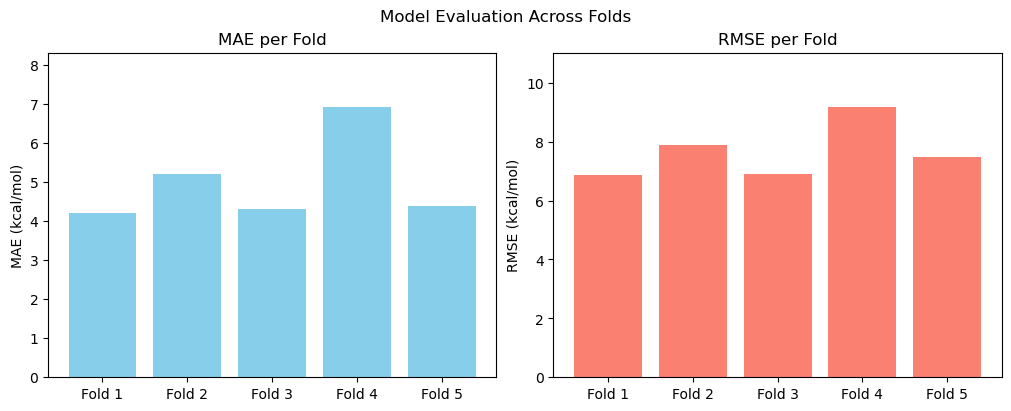

In [5]:
folds = [f"Fold {i+1}" for i in range(5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax1.bar(folds, mae_list, color='skyblue')
ax1.set_title("MAE per Fold")
ax1.set_ylabel("MAE (kcal/mol)")
ax1.set_ylim(0, max(mae_list) * 1.2)

ax2.bar(folds, rmse_list, color='salmon')
ax2.set_title("RMSE per Fold")
ax2.set_ylabel("RMSE (kcal/mol)")
ax2.set_ylim(0, max(rmse_list) * 1.2)

plt.suptitle("Model Evaluation Across Folds")
plt.show()

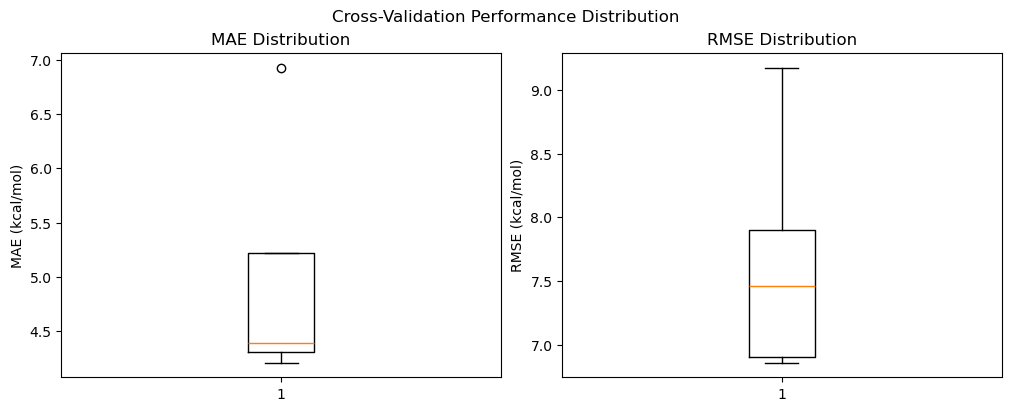

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax[0].boxplot(mae_list)
ax[0].set_title("MAE Distribution")
ax[0].set_ylabel("MAE (kcal/mol)")

ax[1].boxplot(rmse_list)
ax[1].set_title("RMSE Distribution")
ax[1].set_ylabel("RMSE (kcal/mol)")

plt.suptitle("Cross-Validation Performance Distribution")
plt.show()

# Reflection

After evaluating my trained model using the 5-fold cross-validation on the ANI-1 dataset, I got:
- MAE: **5.01 ± 1.01 kcal/mol**
- RMSE: **7.64 ± 0.85 kcal/mol**

The paper's result includes:
- RMSE on random conformers (GDB-10): **1.8 kcal/mol**
- RMSE (relative energies ≤ 30 kcal/mol): **0.6 kcal/mol**
- Final ANI-1 model RMSE: **1.3 kcal/mol**

My model showed a significantly higher RMSE. However, I expected this given the smaller network size, limited training epochs (being only 5), and lacking the advanced training techniques like Gaussian activations, learning rate scheduling, or exponential loss functions. With further training and architectural improvements, I believe I could get my model to be more closely matched with the ANI-1 reported accuracy.
